In [11]:
import geopandas as gpd
import pystac_client
import xarray as xr
import matplotlib.pyplot as plt

from helpers.simplecube import load_xarray, save_xarray, simple_cube

STAC_URL = "https://data.inpe.br/bdc/stac/v1"

def format_bbox(bbox_string):
    return ",".join(map(str, bbox))

def get_composition(cube_id, reject: any = []):
    service = pystac_client.Client.open(STAC_URL)
    collection = service.get_collection(cube_id)
    item_assets = collection.to_dict()['item_assets']
    composition = [ id for id in list(item_assets.keys()) if id not in reject]
    return composition

In [6]:
tile = gpd.read_file("./dataset/tile_C51L41_WGS84.gpkg")
if tile.crs != "EPSG:4326":
    tile = tile.to_crs(epsg=4326)
bbox = list([ float(b) for b in tile.total_bounds ])
bbox

[-61.25000000000001, -8.25, -61.0, -7.999999999999998]

In [7]:
cube = "S2-16D-2"
year = 2024

start, end = (f"{year}-01-01", f"{year}-12-31")
composition = get_composition(cube, reject = ["thumbnail", "CMASK", "CLEAROB", "TOTALOB", "DATASOURCE", "PROVENANCE", "SCL"])
bbox = format_bbox(bbox)
composition
bbox

'-61.25000000000001,-8.25,-61.0,-7.999999999999998'

In [ ]:
output_dir = "./dataset/rasters"
os.makedirs(output_dir, exist_ok = True)

cube = simple_cube(
     stac_url   = STAC_URL,
     collection = cube,
     start_date = start,
     end_date   = end,
     bbox       = bbox,
     bands      = composition
)
save_xarray(cube, f'{output_dir}/cube_sentinel2_{year}.nc')

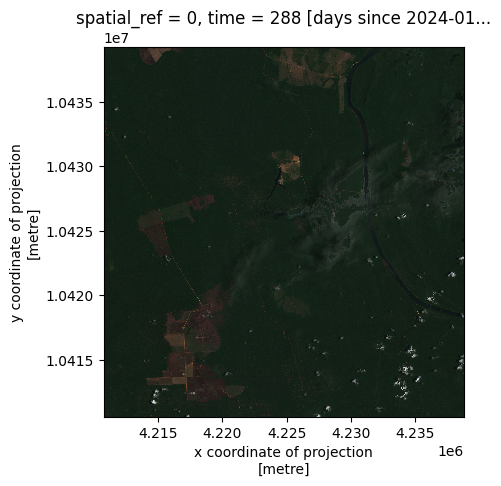

In [19]:
cube = load_xarray(f'./dataset/rasters/cube_sentinel2_{year}.nc')

r, g, b = ['red', 'green', 'blue']

rgb_composition = xr.concat([cube[var].isel(time=18, band=0) for var in [r, g, b]], dim="band")
rgb_composition = rgb_composition.assign_coords(band=["R", "G", "B"])
rgb_composition = rgb_composition.transpose("y", "x", "band")
rgb_composition = rgb_composition / rgb_composition.max() # normalize
rgb_composition.plot.imshow()
plt.gca().set_aspect('equal')

In [18]:
cube

<xarray.Dataset> Size: 6GB
Dimensions:       (time: 23, band: 1, y: 2869, x: 2792)
Coordinates:
  * band          (band) int64 8B 1
  * x             (x) float64 22kB 4.211e+06 4.211e+06 ... 4.239e+06 4.239e+06
  * y             (y) float64 23kB 1.044e+07 1.044e+07 ... 1.041e+07 1.041e+07
    spatial_ref   int64 8B ...
  * time          (time) int64 184B 0 16 32 48 64 80 ... 272 288 304 320 336 352
Data variables: (12/15)
    coastal       (time, band, y, x) int16 368MB ...
    blue          (time, band, y, x) int16 368MB ...
    green         (time, band, y, x) int16 368MB ...
    red           (time, band, y, x) int16 368MB ...
    red-edge-1    (time, band, y, x) int16 368MB ...
    red-edge-2    (time, band, y, x) int16 368MB ...
    ...            ...
    swir-1        (time, band, y, x) int16 368MB ...
    swir-2        (time, band, y, x) int16 368MB ...
    narrow-nir    (time, band, y, x) int16 368MB ...
    evi           (time, band, y, x) int16 368MB ...
    nbr           (time, band, y, x) int16 368MB ...
    ndvi          (time, band, y, x) int16 368MB ...